# 乾物バンド × 一般加法モデル(GAM) × LOSO

§5で当てはまりが良かった**指数関数(exp)**と乾物特徴を使い、加法モデル
$$ MC = \beta_0 + \sum_j \beta_j\, e^{B_j x_j} $$
を組む(各特徴を単調なexp基底で表現 → 線形結合)。exp基底なので学習範囲外でも単調外挿する。

比較対象:
- **Linear-additive** : 素のRidge(各特徴そのまま=線形加法)
- **Spline-GAM** : 各特徴をスプライン展開+Ridge(標準GAM。外挿は線形)
- **Exp-additive GAM** : 上式(exp基底。外挿は指数)

指標 LOSO macro-RMSE。注目 **ベイスギ**(MC最大298%, 学習上限216%超=外挿)。

In [1]:
import numpy as np, pandas as pd
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.pipeline import make_pipeline

tr = pd.read_csv('../data/train_clean.csv', encoding='shift_jis')
META=['sample number','species number','樹種','含水率']
wn_cols=[c for c in tr.columns if c not in META]
wn=np.array([float(c) for c in wn_cols]); wl=1e7/wn; order=np.argsort(wl); nm=wl[order]
X=tr[wn_cols].values.astype(float)[:,order]
mc=tr['含水率'].values.astype(float); sp=tr['樹種'].values; species=np.unique(sp)
snv=lambda M:(M-M.mean(1,keepdims=True))/(M.std(1,keepdims=True)+1e-8)
sg =lambda M,d:savgol_filter(M,11,2,deriv=d,axis=1)
S,S1,S2=snv(X),sg(snv(X),1),sg(snv(X),2)

# §5でexp/quadの当てはまりが良かった乾物特徴(mean系)を採用
def bd(M,lo,hi): return M[:,(nm>=lo)&(nm<=hi)].mean(1)
FEAT = {
  'CH1270': bd(S1,1260,1300),   # exp R²=0.76(最良)
  'CH1715': bd(S2,1700,1740),   # 高MC域 exp R²=0.47
  'CH2320': bd(S2,2300,2340),
  'CH2210': bd(S2,2200,2240),
  'CL2360': bd(S, 2340,2400),
}
Fmat=np.column_stack(list(FEAT.values())); fnames=list(FEAT)
print('採用特徴', fnames, '| F', Fmat.shape)

採用特徴 ['CH1270', 'CH1715', 'CH2320', 'CH2210', 'CL2360'] | F (1270, 5)


## 1. Exp-additive GAM の実装
各特徴を標準化→1次元 `MC=A·exp(B·z)+C` で B を学習→基底 `exp(B·z)` を作り、全基底にRidge。

In [2]:
class ExpAdditiveGAM:
    """MC = b0 + Σ β_j exp(B_j z_j),  z_j=標準化特徴, B_j は1次元exp当てはめで決定"""
    def __init__(self, alpha=1.0, clip=20.0): self.alpha=alpha; self.clip=clip
    def _basis(self, Xz):
        return np.exp(np.clip(self.B_*Xz, -self.clip, self.clip))
    def fit(self, Xtr, y):
        self.mu_=Xtr.mean(0); self.sd_=Xtr.std(0)+1e-9
        Xz=(Xtr-self.mu_)/self.sd_
        B=[]
        for j in range(Xz.shape[1]):
            z=Xz[:,j]
            try:
                p,_=curve_fit(lambda x,A,Bj,C:A*np.exp(np.clip(Bj*x,-self.clip,self.clip))+C,
                              z,y,p0=[y.std(),0.5,y.mean()],maxfev=20000)
                Bj=np.clip(p[1],-3,3)
            except Exception: Bj=0.0
            B.append(Bj if abs(Bj)>1e-3 else 0.3)  # 退化時は緩い正のexp
        self.B_=np.array(B)
        G=self._basis(Xz)
        self.reg_=make_pipeline(StandardScaler(), Ridge(self.alpha)).fit(G,y)
        return self
    def predict(self, Xte):
        Xz=(Xte-self.mu_)/self.sd_
        return np.clip(self.reg_.predict(self._basis(Xz)),0,400)

def linear_add(): return make_pipeline(StandardScaler(), Ridge(1.0))
def spline_gam(): return make_pipeline(
    SplineTransformer(n_knots=5, degree=3, extrapolation='linear'),
    StandardScaler(with_mean=False), Ridge(1.0))
MODELS={'Linear-additive':linear_add,'Spline-GAM':spline_gam,
        'Exp-additive GAM':lambda:ExpAdditiveGAM(alpha=1.0)}
print('OK', list(MODELS))

OK ['Linear-additive', 'Spline-GAM', 'Exp-additive GAM']


## 2. LOSO 検証

In [3]:
def loso(mf):
    per={}
    for s in species:
        te=sp==s; trn=~te
        m=mf(); m.fit(Fmat[trn], mc[trn])
        p=np.asarray(m.predict(Fmat[te])).ravel()
        per[s]=np.sqrt(np.mean((p-mc[te])**2))
    return per
res={mn:loso(mf) for mn,mf in MODELS.items()}
tbl=pd.DataFrame(res).T; tbl.insert(0,'macro',tbl.mean(1))
tbl=tbl.sort_values('macro')
display(tbl[['macro','ベイスギ','イチョウ','米ヒバ','クリ','ヒノキ','ナラ','トチ']].round(1))

,macro,ベイスギ,イチョウ,米ヒバ,クリ,ヒノキ,ナラ,トチ
Exp-additive GAM,26.0,62.2,33.2,25.6,24.0,29.7,11.4,7.4
Spline-GAM,29.3,65.2,49.1,22.0,25.4,33.5,16.5,15.2
Linear-additive,34.6,89.3,31.7,19.3,21.4,38.8,19.6,6.5


## 3. ベイスギfold: 真値 vs 予測(外挿の様子)と部分依存

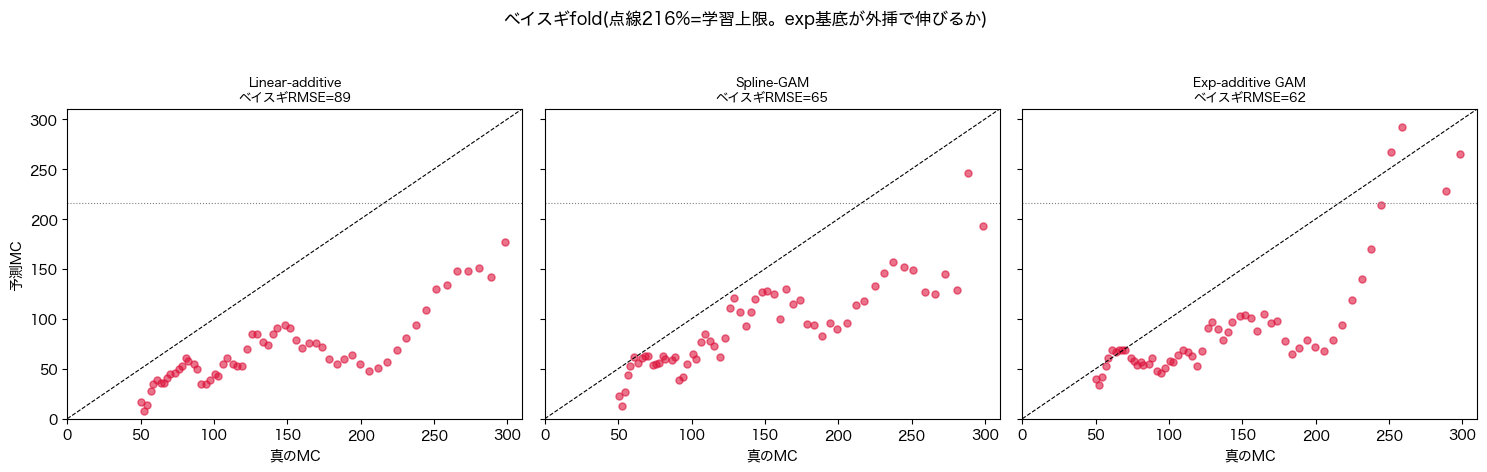

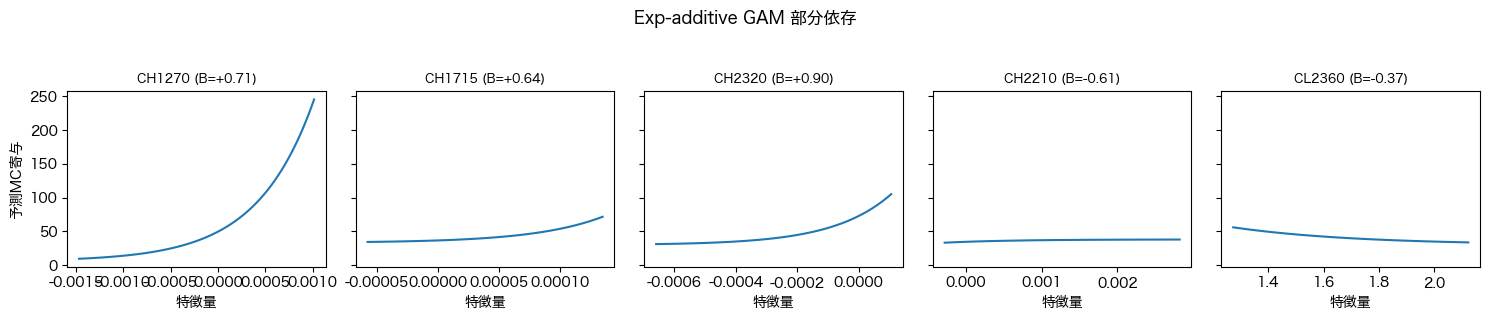

In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['font.family']=['Hiragino Sans','AppleGothic','sans-serif']
matplotlib.rcParams['axes.unicode_minus']=False
ced=sp=='ベイスギ'
fig,ax=plt.subplots(1,3,figsize=(15,4.5),sharex=True,sharey=True)
for a,(mn,mf) in zip(ax,MODELS.items()):
    m=mf(); m.fit(Fmat[~ced],mc[~ced]); p=np.asarray(m.predict(Fmat[ced])).ravel()
    a.scatter(mc[ced],p,s=26,alpha=.6,c='crimson')
    a.plot([0,310],[0,310],'k--',lw=.8); a.axhline(216,color='gray',ls=':',lw=.8)
    a.set_xlim(0,310);a.set_ylim(0,310)
    a.set_title(f'{mn}\nベイスギRMSE={res[mn]["ベイスギ"]:.0f}',fontsize=9); a.set_xlabel('真のMC')
ax[0].set_ylabel('予測MC')
plt.suptitle('ベイスギfold(点線216%=学習上限。exp基底が外挿で伸びるか)',y=1.04)
plt.tight_layout(); plt.show()

# Exp-additive GAM の部分依存(各特徴の寄与形)
g=ExpAdditiveGAM(alpha=1.0).fit(Fmat,mc)
fig,ax=plt.subplots(1,len(fnames),figsize=(3*len(fnames),3),sharey=True)
for a,j in zip(ax,range(len(fnames))):
    xs=np.linspace(Fmat[:,j].min(),Fmat[:,j].max(),100)
    Xq=np.tile(Fmat.mean(0),(100,1)); Xq[:,j]=xs
    a.plot(xs, g.predict(Xq)); a.set_title(f'{fnames[j]} (B={g.B_[j]:+.2f})',fontsize=9)
    a.set_xlabel('特徴量')
ax[0].set_ylabel('予測MC寄与'); plt.suptitle('Exp-additive GAM 部分依存',y=1.05)
plt.tight_layout(); plt.show()